In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import sklearn
print("numpy",np.__version__)
print("pandas",pd.__version__)
print("sklearn",sklearn.__version__)


numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1


In [2]:
df = pd.read_csv('laptop_data.csv')


In [3]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [4]:
df.shape

(8796, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8796 entries, 0 to 8795
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        8796 non-null   int64  
 1   Company           8796 non-null   object 
 2   TypeName          8796 non-null   object 
 3   Inches            8796 non-null   float64
 4   ScreenResolution  8796 non-null   object 
 5   Cpu               8796 non-null   object 
 6   Ram               8796 non-null   object 
 7   Memory            8796 non-null   object 
 8   Gpu               8796 non-null   object 
 9   OpSys             8796 non-null   object 
 10  Weight            8796 non-null   object 
 11  Price             8796 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 824.8+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


In [8]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [9]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [10]:
df['Ram'] = df['Ram'].str.replace('GB','')
df['Weight'] = df['Weight'].str.replace('kg','')

In [11]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [12]:
df['Ram'] = df['Ram'].astype('int32')
df['Weight'] = df['Weight'].astype('float32')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8796 entries, 0 to 8795
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           8796 non-null   object 
 1   TypeName          8796 non-null   object 
 2   Inches            8796 non-null   float64
 3   ScreenResolution  8796 non-null   object 
 4   Cpu               8796 non-null   object 
 5   Ram               8796 non-null   int32  
 6   Memory            8796 non-null   object 
 7   Gpu               8796 non-null   object 
 8   OpSys             8796 non-null   object 
 9   Weight            8796 non-null   float32
 10  Price             8796 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 687.3+ KB


In [14]:
import seaborn as sns

/tmp/ipykernel_852/834922981.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


<Axes: xlabel='Price', ylabel='Density'>

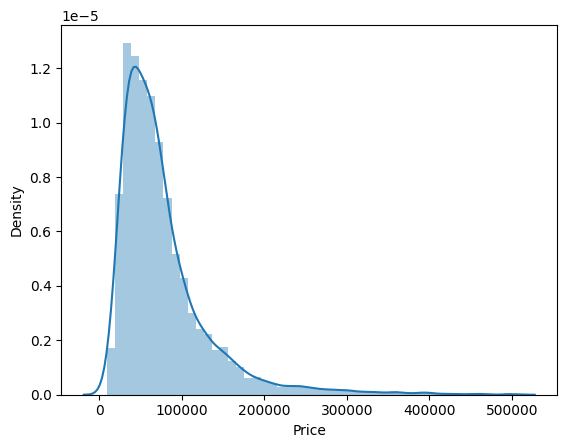

In [15]:
sns.distplot(df['Price'])

<Axes: xlabel='Company'>

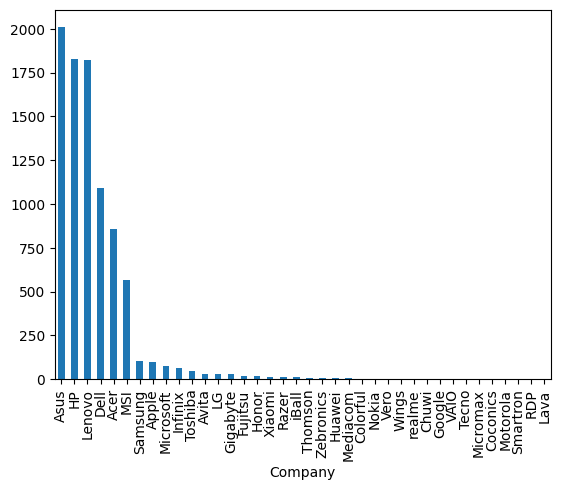

In [16]:
df['Company'].value_counts().plot(kind='bar')

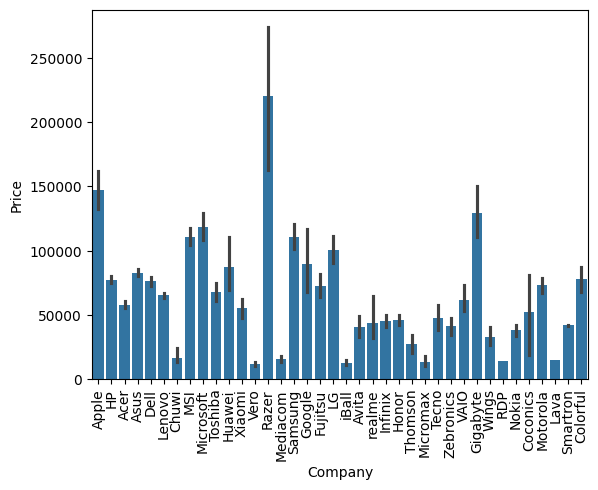

In [17]:
sns.barplot(x=df['Company'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName'>

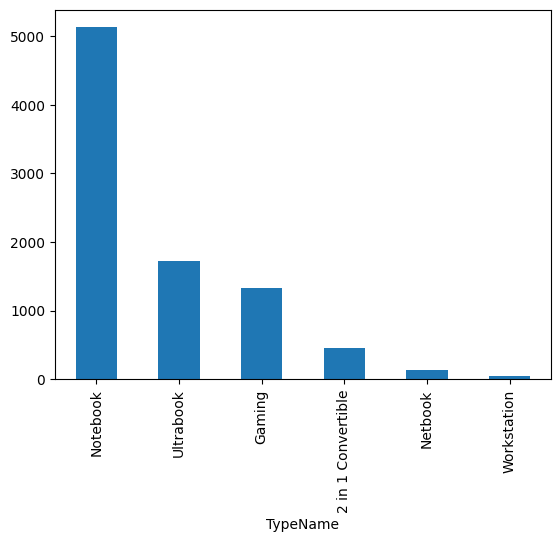

In [18]:
df['TypeName'].value_counts().plot(kind='bar')

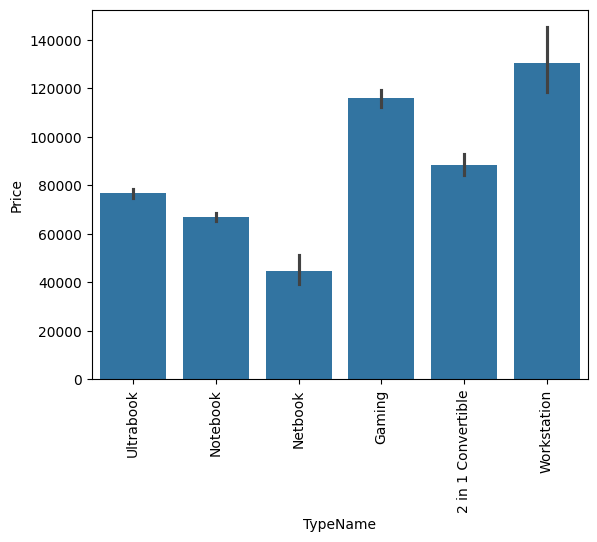

In [19]:
sns.barplot(x=df['TypeName'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

/tmp/ipykernel_852/1439577752.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Inches'])


<Axes: xlabel='Inches', ylabel='Density'>

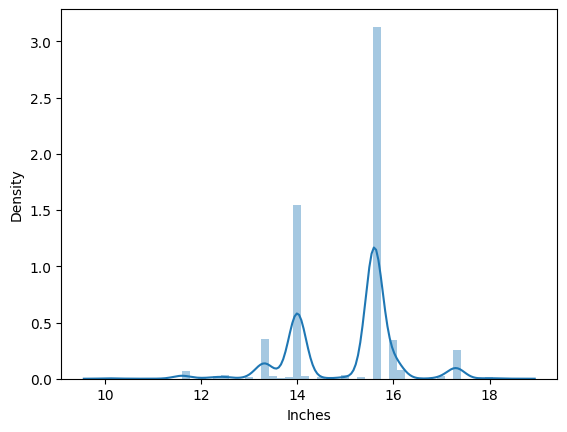

In [20]:
sns.distplot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price'>

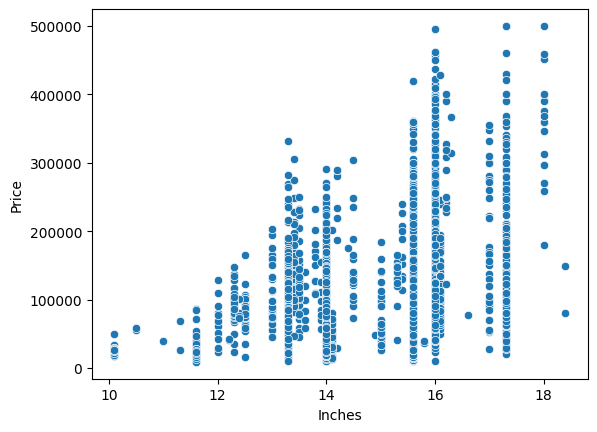

In [21]:
sns.scatterplot(x=df['Inches'],y=df['Price'])

In [22]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
1920x1080,2549
IPS Panel 1920x1080,2136
1366x768,1071
Full HD 1920x1080,505
IPS Panel 1920x1200,305
...,...
Touchscreen 2304x1536,1
Touchscreen IPS Panel 2560x1440,1
IPS Panel 2561x1600,1


In [23]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [24]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen
7477,Lenovo,Notebook,14.0,1366x768,Intel Core i3-8130U (8th Gen),4,1000GB HDD,Intel UHD 620,Windows 10 Home Basic,1.60,39000.0,0
2208,Acer,Notebook,15.6,1920x1080,AMD Hexa-Core Ryzen 5 - 5625U,16,1000GB SSD,AMD Radeon,Windows 11 Home Basic,1.59,37999.0,0
7746,Asus,Gaming,14.0,2560x1440,AMD Octa Core Ryzen 9 4900HS,16,1000GB SSD,NVIDIA GeForce GTX 1660Ti,Windows 10 Home Basic,1.70,119990.0,0
6071,HP,Notebook,17.3,IPS Panel 2560x1440,Intel Core i7-13700HX (13th Gen),16,1000GB SSD,NVIDIA GeForce RTX 4090,Windows 11 Home Basic,2.78,289990.0,0
1458,Dell,Notebook,15.6,1920x1080,Intel Core i5-1135G7 (11th Gen),8,256GB SSD + 1000GB HDD,Intel Iris Xe,Windows 10 Home Basic,1.83,60414.0,0


<Axes: xlabel='Touchscreen'>

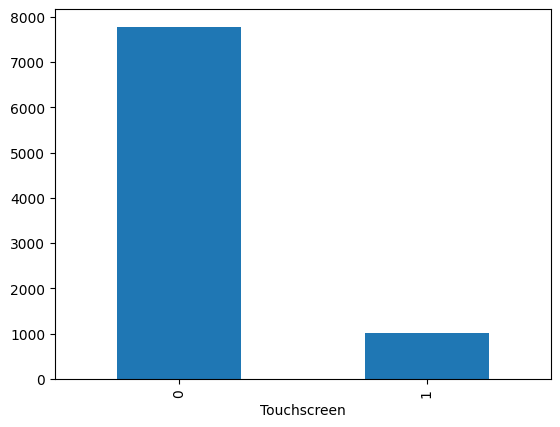

In [25]:
df['Touchscreen'].value_counts().plot(kind='bar')

<Axes: xlabel='Touchscreen', ylabel='Price'>

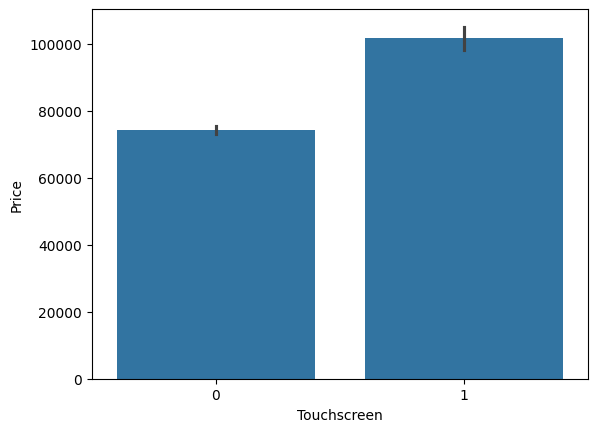

In [26]:
sns.barplot(x=df['Touchscreen'],y=df['Price'])

In [27]:
df['Ips'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [28]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1


<Axes: xlabel='Ips'>

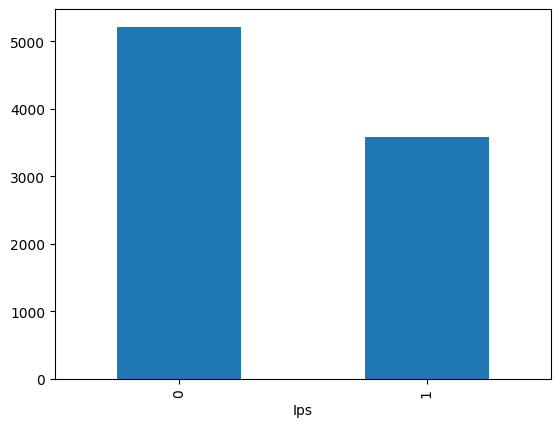

In [29]:
df['Ips'].value_counts().plot(kind='bar')

<Axes: xlabel='Ips', ylabel='Price'>

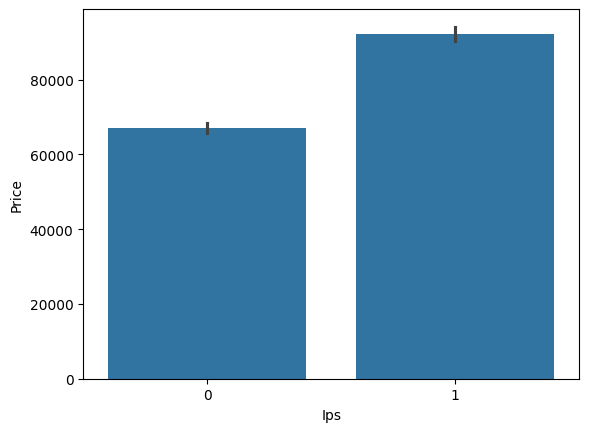

In [30]:
sns.barplot(x=df['Ips'],y=df['Price'])

In [31]:
new = df['ScreenResolution'].str.split('x',n=1,expand=True)

In [32]:
df['X_res'] = new[0]
df['Y_res'] = new[1]

In [33]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res
7236,Asus,Ultrabook,13.3,1920x1080,Intel Core i5-8265U (8th Gen),8,256GB SSD,Intel UHD 620,Windows 10 Home Basic,1.19,69990.0,0,0,1920,1080
3045,HP,Ultrabook,14.0,Touchscreen IPS Panel 1920x1080,Intel Core i5-1235U (12th Gen),16,512GB SSD,Intel Iris Xe,Windows 11 Home Basic,1.41,59985.0,1,1,Touchscreen IPS Panel 1920,1080
3664,Asus,Gaming,15.6,IPS Panel 1920x1080,Intel Core i9-10980HK (10th Gen),32,2000GB SSD,NVIDIA Geforce RTX 2080 Super with Max-Q Design,Windows 10 Home Basic,2.48,349990.0,0,1,IPS Panel 1920,1080
6614,Lenovo,Notebook,15.6,IPS Panel 1920x1080,AMD Hexa-Core Ryzen 5 - 5625U,16,512GB SSD,AMD Radeon,Windows 11 Home Basic,1.61,38990.0,0,1,IPS Panel 1920,1080
5405,Lenovo,Notebook,15.6,IPS Panel 1920x1080,Intel Core i5-8250U (8th Gen),8,1000GB HDD,Intel UHD 620,Windows 10 Home Basic,2.20,54990.0,0,1,IPS Panel 1920,1080


In [34]:
df['X_res'] = df['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [35]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


In [36]:
df['X_res'] = df['X_res'].astype('int')
df['Y_res'] = df['Y_res'].astype('int')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8796 entries, 0 to 8795
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           8796 non-null   object 
 1   TypeName          8796 non-null   object 
 2   Inches            8796 non-null   float64
 3   ScreenResolution  8796 non-null   object 
 4   Cpu               8796 non-null   object 
 5   Ram               8796 non-null   int32  
 6   Memory            8796 non-null   object 
 7   Gpu               8796 non-null   object 
 8   OpSys             8796 non-null   object 
 9   Weight            8796 non-null   float32
 10  Price             8796 non-null   float64
 11  Touchscreen       8796 non-null   int64  
 12  Ips               8796 non-null   int64  
 13  X_res             8796 non-null   int64  
 14  Y_res             8796 non-null   int64  
dtypes: float32(1), float64(2), int32(1), int64(4), object(7)
memory usage: 962.2+ KB


In [38]:
df.corr(numeric_only=True)['Price']

,Price
Inches,0.157951
Ram,0.756682
Weight,0.251181
Price,1.000000
Touchscreen,0.153719
Ips,0.217510
X_res,0.552464
Y_res,0.570756


In [39]:
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5/df['Inches']).astype('float')

In [40]:
df.corr(numeric_only=True)['Price']

,Price
Inches,0.157951
Ram,0.756682
Weight,0.251181
Price,1.000000
Touchscreen,0.153719
Ips,0.217510
X_res,0.552464
Y_res,0.570756
ppi,0.467076


In [41]:
df.drop(columns=['ScreenResolution'],inplace=True)

In [42]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res,ppi
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005


In [43]:
df.drop(columns=['Inches','X_res','Y_res'],inplace=True)

In [44]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005


In [45]:
df['Cpu'].value_counts()

,count
Cpu,
Intel Core i5-1135G7 (11th Gen),366
Intel Core i3-1115G4 (11th Gen),267
Intel Core i5-1235U (12th Gen),202
Intel Core i3-1005G1 (10th Gen),193
Intel Core i5 7200U 2.5GHz,190
...,...
MediaTek Octa Core P60T,1
AMD Dual Core A6 9220E,1
AMDAMD Dual Core Ryzen 3 3250U,1


In [46]:
df['Cpu Name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [47]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [48]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

In [49]:
df['Cpu brand'] = df['Cpu Name'].apply(fetch_processor)

In [50]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu Name,Cpu brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5


<Axes: xlabel='Cpu brand'>

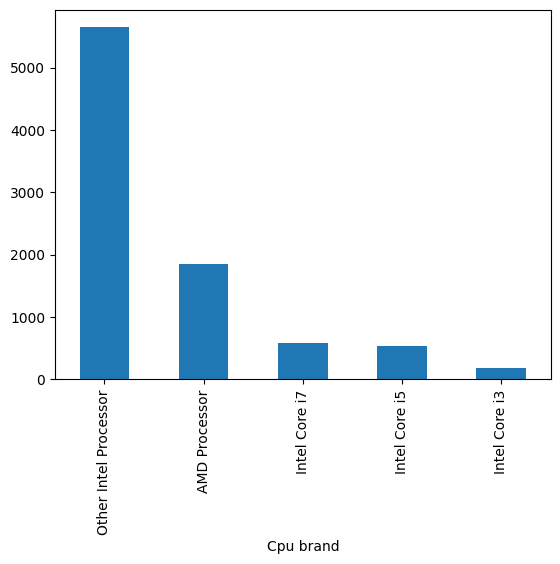

In [51]:
df['Cpu brand'].value_counts().plot(kind='bar')

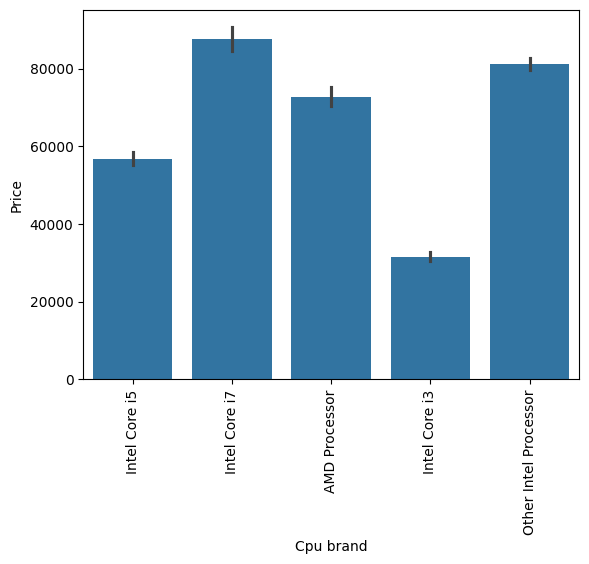

In [52]:
sns.barplot(x=df['Cpu brand'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [53]:
df.drop(columns=['Cpu','Cpu Name'],inplace=True)

In [54]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


<Axes: xlabel='Ram'>

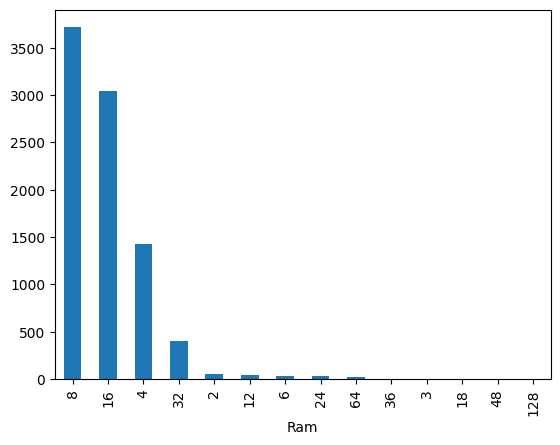

In [55]:
df['Ram'].value_counts().plot(kind='bar')

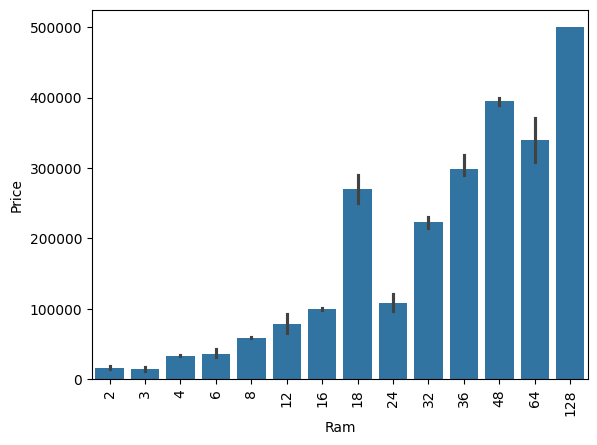

In [56]:
sns.barplot(x=df['Ram'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [57]:
df['Memory'].value_counts()

,count
Memory,
512GB SSD,3623
1000GB SSD,1388
1000GB HDD,1073
256GB SSD,1019
256GB SSD + 1000GB HDD,386
...,...
32GB SSD + 500GB HDD,1
64GB SSD + 1000GB HDD,1
1GB HDD,1


In [58]:
df['Memory'] = df['Memory'].astype(str).replace(r'\.0', '', regex=True)

df['Memory'] = df['Memory'].str.replace('GB', '', regex=False)
df['Memory'] = df['Memory'].str.replace('TB', '000', regex=False)

new = df['Memory'].str.split('+', n=1, expand=True)

df['first'] = new[0].str.strip()
df['second'] = new[1]

df['Layer1HDD'] = df['first'].apply(lambda x: 1 if 'HDD' in x else 0)
df['Layer1SSD'] = df['first'].apply(lambda x: 1 if 'SSD' in x else 0)
df['Layer1Hybrid'] = df['first'].apply(lambda x: 1 if 'Hybrid' in x else 0)
df['Layer1Flash_Storage'] = df['first'].apply(lambda x: 1 if 'Flash Storage' in x else 0)

df['first'] = df['first'].str.replace(r'\D', '', regex=True)

df['second'] = df['second'].fillna('0')

df['Layer2HDD'] = df['second'].apply(lambda x: 1 if 'HDD' in x else 0)
df['Layer2SSD'] = df['second'].apply(lambda x: 1 if 'SSD' in x else 0)
df['Layer2Hybrid'] = df['second'].apply(lambda x: 1 if 'Hybrid' in x else 0)
df['Layer2Flash_Storage'] = df['second'].apply(lambda x: 1 if 'Flash Storage' in x else 0)

df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df['first'] = df['first'].astype(int)
df['second'] = df['second'].astype(int)

df['HDD'] = df['first'] * df['Layer1HDD'] + df['second'] * df['Layer2HDD']
df['SSD'] = df['first'] * df['Layer1SSD'] + df['second'] * df['Layer2SSD']
df['Hybrid'] = df['first'] * df['Layer1Hybrid'] + df['second'] * df['Layer2Hybrid']
df['Flash_Storage'] = (
    df['first'] * df['Layer1Flash_Storage'] +
    df['second'] * df['Layer2Flash_Storage']
)

df.drop(columns=[
    'first', 'second',
    'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid', 'Layer1Flash_Storage',
    'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid', 'Layer2Flash_Storage'
], inplace=True)

In [59]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
5333,HP,2 in 1 Convertible,16,512 SSD,Intel Iris Xe,Windows 11 Home Basic,1.52,73999.00,1,1,157.350512,Other Intel Processor,0,512,0,0
7277,Asus,Ultrabook,8,512 SSD,NVIDIA Geforce MX150,Windows 10 Home Basic,1.19,89990.00,0,0,165.632118,Other Intel Processor,0,512,0,0
2560,Lenovo,Notebook,4,1000 HDD,Intel UHD 620,DOS,1.55,29490.00,0,0,111.935204,Other Intel Processor,1000,0,0,0
2573,Asus,Gaming,8,1000 SSD,NVIDIA GeForce RTX 3050,Windows 10 Home Basic,2.30,90970.00,0,1,141.211998,Other Intel Processor,0,1000,0,0
786,MSI,Gaming,8,128 SSD + 1000 HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,58021.92,0,0,141.211998,Intel Core i5,1000,128,0,0


In [60]:
df.drop(columns=['Memory'],inplace=True)

In [61]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0


In [62]:
df.corr(numeric_only=True)['Price']

,Price
Ram,0.756682
Weight,0.251181
Price,1.000000
Touchscreen,0.153719
Ips,0.217510
ppi,0.467076
HDD,-0.227331
SSD,0.661545
Hybrid,-0.004238
Flash_Storage,-0.025663


In [63]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [64]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256


In [65]:
df['Gpu'].value_counts()

,count
Gpu,
Intel UHD,1215
Intel Iris Xe,974
AMD Radeon,629
NVIDIA GeForce RTX 3050,415
Intel HD Graphics 620,280
...,...
NVIDIA Geforce RTX 2070 Super Max-Q,1
Intel Integrated Grphics,1
NVIDIA Geforce GTX 2060,1


In [66]:
df['Gpu brand'] = df['Gpu'].apply(lambda x:x.split()[0])

In [67]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


In [68]:
df['Gpu brand'].value_counts()

,count
Gpu brand,
Intel,4249
NVIDIA,2731
AMD,1311
Nvidia,415
Apple,37
Qualcomm,37
Radeon,5
ARM,3
ATI,2


In [69]:
df = df[df['Gpu brand'] != 'ARM']

In [70]:
df['Gpu brand'].value_counts()

,count
Gpu brand,
Intel,4249
NVIDIA,2731
AMD,1311
Nvidia,415
Apple,37
Qualcomm,37
Radeon,5
ATI,2
MediaTek,2


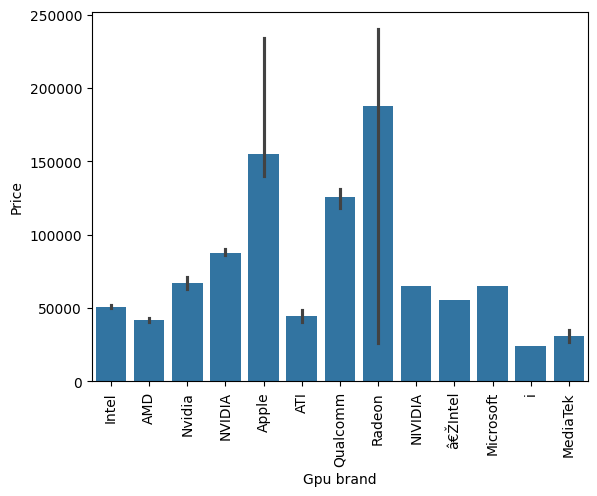

In [71]:
sns.barplot(x=df['Gpu brand'],y=df['Price'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

In [72]:
df.drop(columns=['Gpu'],inplace=True)

In [73]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


In [74]:
df['OpSys'].value_counts()

,count
OpSys,
Windows 11 Home Basic,3435
Windows 10 Home Basic,2729
Windows 10,1177
DOS,358
Windows 11 Professional,264
Windows 10 Professional,198
Windows 11,143
Linux,103
No OS,66


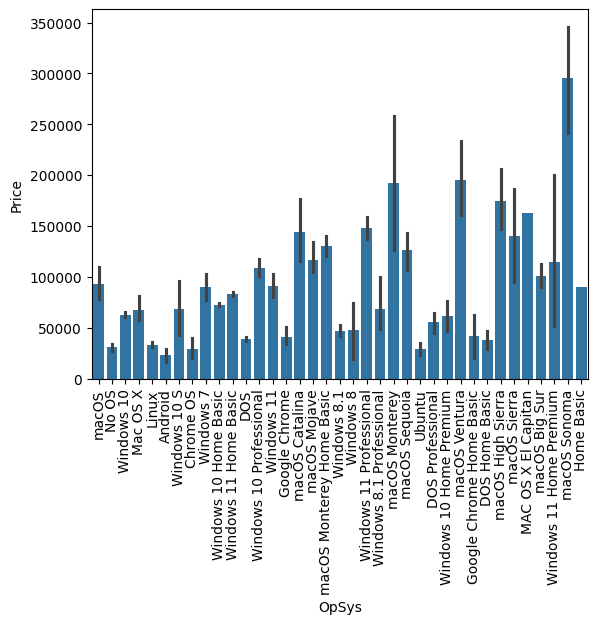

In [75]:
sns.barplot(x=df['OpSys'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [76]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

In [77]:
df['os'] = df['OpSys'].apply(cat_os)

In [78]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [79]:
df.drop(columns=['OpSys'],inplace=True)

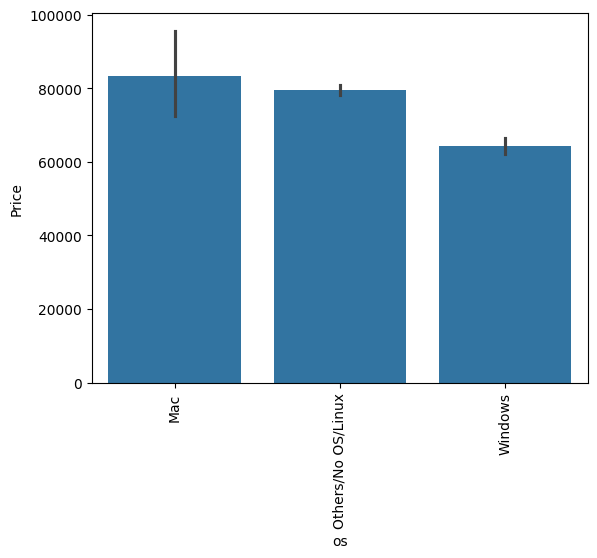

In [80]:
sns.barplot(x=df['os'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

/tmp/ipykernel_852/1125578356.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

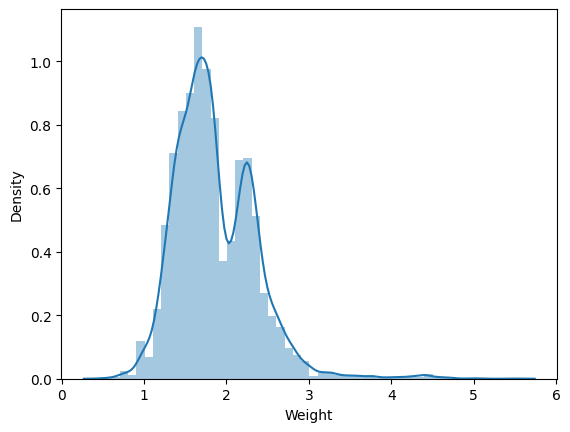

In [81]:
sns.distplot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Price'>

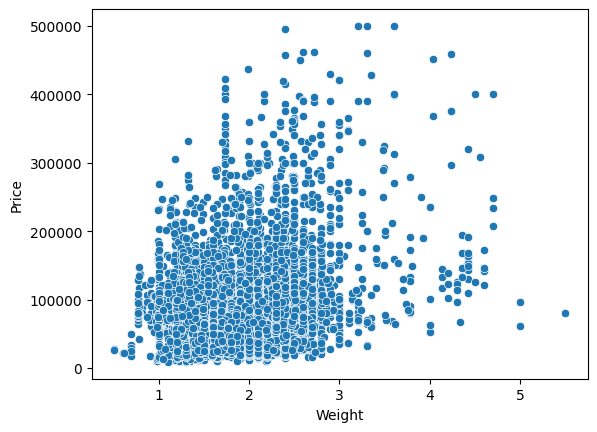

In [82]:
sns.scatterplot(x=df['Weight'],y=df['Price'])

In [83]:
df.corr(numeric_only=True)['Price']

,Price
Ram,0.756614
Weight,0.251182
Price,1.000000
Touchscreen,0.154742
Ips,0.217940
ppi,0.467702
HDD,-0.227540
SSD,0.661450


<Axes: >

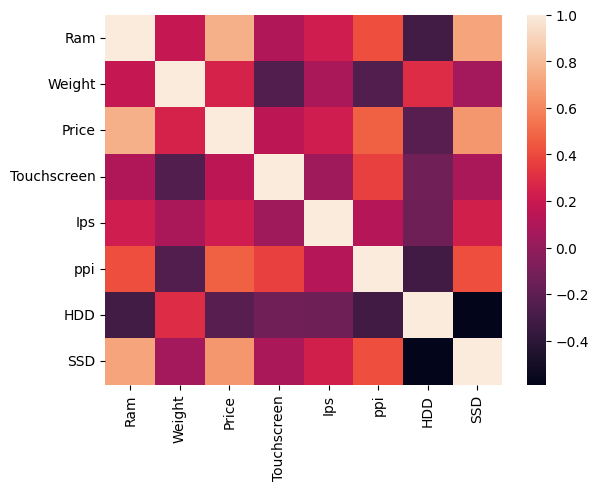

In [84]:
sns.heatmap(df.corr(numeric_only=True))

/tmp/ipykernel_852/3556049916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['Price']))


<Axes: xlabel='Price', ylabel='Density'>

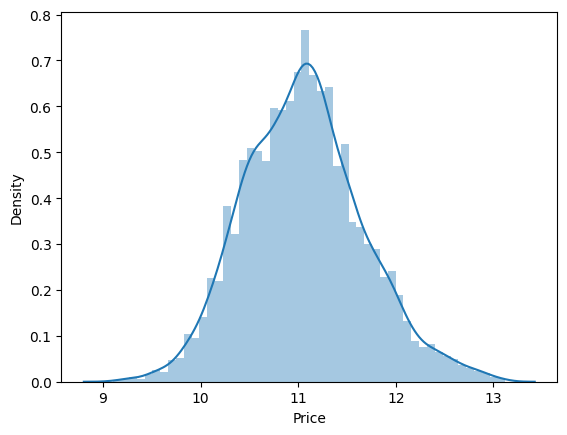

In [85]:
sns.distplot(np.log(df['Price']))

In [86]:
X = df.drop(columns=['Price'])
y = np.log(df['Price'])

In [87]:
X

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...
8791,Acer,Notebook,32,2.10,0,1,282.423996,Other Intel Processor,0,1000,NVIDIA,Others/No OS/Linux
8792,Acer,Notebook,32,2.10,0,1,282.423996,Other Intel Processor,0,512,NVIDIA,Others/No OS/Linux
8793,Lenovo,Ultrabook,8,1.22,0,0,165.632118,Other Intel Processor,0,512,Intel,Others/No OS/Linux
8794,Lenovo,Notebook,8,1.77,0,0,157.350512,Other Intel Processor,0,256,Intel,Others/No OS/Linux


In [88]:
y

,Price
0,11.175755
1,10.776777
2,10.329931
3,11.814476
4,11.473101
...,...
8791,12.472272
8792,12.452929
8793,11.660483
8794,10.986529


In [89]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15,random_state=2)

In [90]:
X_train

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
8778,Lenovo,Notebook,4,1.60,0,0,111.935204,Other Intel Processor,1000,0,Intel,Others/No OS/Linux
6880,Dell,Notebook,8,1.66,0,0,141.211998,Other Intel Processor,0,512,Intel,Others/No OS/Linux
8788,Lenovo,Gaming,8,2.41,0,0,141.211998,Other Intel Processor,2000,128,NVIDIA,Others/No OS/Linux
3680,Asus,Ultrabook,8,1.50,0,0,157.350512,Other Intel Processor,0,512,Intel,Others/No OS/Linux
3263,HP,Notebook,8,1.74,0,0,141.211998,Other Intel Processor,1000,256,Intel,Others/No OS/Linux
...,...,...,...,...,...,...,...,...,...,...,...,...
1099,Asus,Gaming,16,4.30,0,1,127.335675,Intel Core i7,1000,128,Nvidia,Windows
2515,MSI,Notebook,32,2.30,0,1,141.211998,Other Intel Processor,1000,512,NVIDIA,Others/No OS/Linux
6638,Lenovo,Notebook,24,2.38,0,1,141.211998,AMD Processor,0,512,NVIDIA,Others/No OS/Linux
2576,Dell,Notebook,8,1.68,0,0,141.211998,AMD Processor,0,512,AMD,Others/No OS/Linux


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [92]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

### Linear regression

In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

step1 = ColumnTransformer(
    transformers=[
        ('col_tnf',
         OneHotEncoder(
             sparse_output=False,
             drop='first',
             handle_unknown='ignore'
         ),
         [0, 1, 7, 10, 11])
    ],
    remainder='passthrough'
)

step2 = LinearRegression()

linear_pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

linear_pipe.fit(X_train, y_train)

y_pred = linear_pipe.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

from sklearn.metrics import mean_squared_error

# Use the number of columns after one-hot encoding for adjusted R².
n = len(y_test)
p = linear_pipe.named_steps['step1'].transform(X_test.iloc[:1]).shape[1]
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R2:", adjusted_r2)
print("MSE:", mean_squared_error(y_test, y_pred))


R2 Score: 0.7406073590350475
MAE: 0.22896165419118575
Adjusted R2: 0.7269333060768312
MSE: 0.09660785217974137


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Decision Tree


In [94]:
# Decision Tree Regression

from sklearn.tree import DecisionTreeRegressor

step1 = ColumnTransformer(
    transformers=[
        ('col_tnf',
         OneHotEncoder(
             sparse_output=False,
             drop='first',
             handle_unknown='ignore'
         ),
         [0, 1, 7, 10, 11])
    ],
    remainder='passthrough'
)

step2 = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

decision_tree_pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

decision_tree_pipe.fit(X_train, y_train)

y_pred = decision_tree_pipe.predict(X_test)

print("Decision Tree R2 Score:",
      r2_score(y_test, y_pred))

print("Decision Tree MAE:",
      mean_absolute_error(y_test, y_pred))

from sklearn.metrics import mean_squared_error

# Use the number of columns after one-hot encoding for adjusted R².
n = len(y_test)
p = decision_tree_pipe.named_steps['step1'].transform(X_test.iloc[:1]).shape[1]
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R2:", adjusted_r2)
print("MSE:", mean_squared_error(y_test, y_pred))


Decision Tree R2 Score: 0.7981762874070458
Decision Tree MAE: 0.20743477001883975
Adjusted R2: 0.7875370182128486
MSE: 0.07516695662611775


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Random Forest

In [95]:
from sklearn.ensemble import RandomForestRegressor

step1 = ColumnTransformer(
    transformers=[
        ('col_tnf',
         OneHotEncoder(
             sparse_output=False,
             drop='first',
             handle_unknown='ignore'
         ),
         [0, 1, 7, 10, 11])
    ],
    remainder='passthrough'
)

step2 = RandomForestRegressor(
    n_estimators=100,
    random_state=3,
    max_samples=0.5,
    max_features=0.75,
    max_depth=15,
    n_jobs=-1
)

random_forest_pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

random_forest_pipe.fit(X_train, y_train)

y_pred = random_forest_pipe.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

from sklearn.metrics import mean_squared_error

# Use the number of columns after one-hot encoding for adjusted R².
n = len(y_test)
p = random_forest_pipe.named_steps['step1'].transform(X_test.iloc[:1]).shape[1]
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R2:", adjusted_r2)
print("MSE:", mean_squared_error(y_test, y_pred))


R2 Score: 0.8413822093656602
MAE: 0.18347564034864602
Adjusted R2: 0.8330205686453196
MSE: 0.05907540018743206


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### XGBoost (Optional / Keep for comparison)

In [96]:
from xgboost import XGBRegressor

step1 = ColumnTransformer(
    transformers=[
        ('col_tnf',
         OneHotEncoder(
             sparse_output=False,
             drop='first',
             handle_unknown='ignore'
         ),
         [0, 1, 7, 10, 11])
    ],
    remainder='passthrough'
)

step2 = XGBRegressor(
    n_estimators=45,
    max_depth=5,
    learning_rate=0.5,
    random_state=42
)

xgboost_pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

xgboost_pipe.fit(X_train, y_train)

y_pred = xgboost_pipe.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

from sklearn.metrics import mean_squared_error

# Use the number of columns after one-hot encoding for adjusted R².
n = len(y_test)
p = xgboost_pipe.named_steps['step1'].transform(X_test.iloc[:1]).shape[1]
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R2:", adjusted_r2)
print("MSE:", mean_squared_error(y_test, y_pred))


R2 Score: 0.8370473379850688
MAE: 0.18618513575671902
Adjusted R2: 0.8284571816807673
MSE: 0.060689873951978654


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Five-fold cross-validation

The original 85:15 split gives one test result. Cross-validation checks whether the model comparison changes with different validation rows. It splits **only the training portion** into five folds, fits the complete pipeline on four folds and scores the fifth, repeating five times. The table shows the average score and its variation; the 15% test portion remains separate.


In [97]:
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Linear Regression": linear_pipe,
    "Decision Tree": decision_tree_pipe,
    "Random Forest": random_forest_pipe,
    "XGBoost": xgboost_pipe
}

cv_rows = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "R2": "r2",
            "MAE": "neg_mean_absolute_error",
            "MSE": "neg_mean_squared_error"
        },
        n_jobs=1
    )

    cv_rows.append({
        "Model": name,
        "CV R2 mean": scores["test_R2"].mean(),
        "CV R2 std": scores["test_R2"].std(),
        "CV MAE mean": -scores["test_MAE"].mean(),
        "CV MAE std": scores["test_MAE"].std(),
        "CV MSE mean": -scores["test_MSE"].mean()
    })

cv_results = (
    pd.DataFrame(cv_rows)
      .sort_values("CV R2 mean", ascending=False)
      .reset_index(drop=True)
)

print(cv_results.round(4).to_string(index=False))

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown ca

            Model  CV R2 mean  CV R2 std  CV MAE mean  CV MAE std  CV MSE mean
          XGBoost      0.8326     0.0072       0.1909      0.0043       0.0634
    Random Forest      0.8303     0.0053       0.1915      0.0050       0.0644
    Decision Tree      0.7730     0.0070       0.2209      0.0055       0.0861
Linear Regression      0.7618     0.0040       0.2302      0.0052       0.0904


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


**Reading the results:** Among the three models included in the final comparison, Random Forest gives the highest mean CV R² (0.8303) and the lowest mean CV MAE (0.1915), so it is selected as the final model. It is then evaluated once on the untouched test set. All reported errors use log price. The separate XGBoost code is retained only for possible future experimentation and is not part of this model-selection decision.


### Model Comparison and Final Model

- Linear Regression: R² = 0.7406, MAE = 0.2290
- Decision Tree: R² = 0.7982, MAE = 0.2074
- Random Forest: R² = 0.8414, MAE = 0.1835

Random Forest is selected as the final model because it gives the best mean cross-validation performance among Linear Regression, Decision Tree and Random Forest: mean CV R² = 0.8303 and mean CV MAE = 0.1915. After selection, it is evaluated once on the untouched test set, where it achieves R² = 0.8414, Adjusted R² = 0.8330, MAE = 0.1835 and MSE = 0.0591.

**Held-out test results:** Linear Regression / Decision Tree / Random Forest — R² = 0.7406 / 0.7982 / 0.8414; Adjusted R² = 0.7269 / 0.7875 / 0.8330; MAE = 0.2290 / 0.2074 / 0.1835; MSE = 0.0966 / 0.0752 / 0.0591.

### Updated CV Wording

**Difficult 1st Project — Laptop Price Estimation through Hardware Feature Engineering**

- Analyzed **8,796 laptop configurations** using EDA and correlation analysis to identify hardware and display characteristics associated with price.
- Transformed semi-structured specifications into predictive features, extracting **RAM, storage, CPU/GPU categories, display resolution and PPI** instead of directly using raw specifications.
- Built an end-to-end regression workflow using **ColumnTransformer and Scikit-Learn Pipeline** to one-hot encode categorical variables, retain numerical variables and apply the same preprocessing consistently during training, cross-validation and prediction.
- Compared **Linear Regression, Decision Tree and Random Forest using 5-fold cross-validation on the training set**; selected Random Forest based on the best mean CV performance (**R² = 0.8303, MAE = 0.1915**) and achieved **test R² = 0.8414, Adjusted R² = 0.8330, MAE = 0.1835 and MSE = 0.0591** on the untouched test set, improving over the Linear Regression baseline (**R² = 0.7406, Adjusted R² = 0.7269, MAE = 0.2290 and MSE = 0.0966**).

**Easy 1st Project — Laptop Price Estimation through Hardware Feature Engineering**

- Analyzed **8,796 laptop configurations** using EDA and correlation analysis to identify hardware features associated with price.
- Extracted useful features such as **RAM, storage, CPU/GPU categories, display resolution and PPI** from raw laptop specifications.
- Compared **Linear Regression, Decision Tree and Random Forest using 5-fold cross-validation** and selected Random Forest based on its best average validation performance. It achieved **test R² = 0.8414, Adjusted R² = 0.8330 and MAE = 0.1835**, improving over the Linear Regression baseline (**R² = 0.7406, Adjusted R² = 0.7269 and MAE = 0.2290**).

### Exporting the Final Model

In [98]:
# Random Forest is selected using CV among Linear Regression, Decision Tree and Random Forest.
# The separate XGBoost code is retained only for possible future experimentation.
final_model = random_forest_pipe

# import pickle
# with open('pipe.pkl', 'wb') as file:
#   pickle.dump(final_model, file)
# with open('df.pkl', 'wb') as file:
#   pickle.dump(df, file)

# pickle.dump(df,open('df.pkl','wb'))
# pickle.dump(final_model,open('pipe.pkl','wb'))

In [99]:
df

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8791,Acer,Notebook,32,2.10,260999.0000,0,1,282.423996,Other Intel Processor,0,1000,NVIDIA,Others/No OS/Linux
8792,Acer,Notebook,32,2.10,255999.0000,0,1,282.423996,Other Intel Processor,0,512,NVIDIA,Others/No OS/Linux
8793,Lenovo,Ultrabook,8,1.22,115900.0000,0,0,165.632118,Other Intel Processor,0,512,Intel,Others/No OS/Linux
8794,Lenovo,Notebook,8,1.77,59073.0000,0,0,157.350512,Other Intel Processor,0,256,Intel,Others/No OS/Linux


In [100]:
X_train

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
8778,Lenovo,Notebook,4,1.60,0,0,111.935204,Other Intel Processor,1000,0,Intel,Others/No OS/Linux
6880,Dell,Notebook,8,1.66,0,0,141.211998,Other Intel Processor,0,512,Intel,Others/No OS/Linux
8788,Lenovo,Gaming,8,2.41,0,0,141.211998,Other Intel Processor,2000,128,NVIDIA,Others/No OS/Linux
3680,Asus,Ultrabook,8,1.50,0,0,157.350512,Other Intel Processor,0,512,Intel,Others/No OS/Linux
3263,HP,Notebook,8,1.74,0,0,141.211998,Other Intel Processor,1000,256,Intel,Others/No OS/Linux
...,...,...,...,...,...,...,...,...,...,...,...,...
1099,Asus,Gaming,16,4.30,0,1,127.335675,Intel Core i7,1000,128,Nvidia,Windows
2515,MSI,Notebook,32,2.30,0,1,141.211998,Other Intel Processor,1000,512,NVIDIA,Others/No OS/Linux
6638,Lenovo,Notebook,24,2.38,0,1,141.211998,AMD Processor,0,512,NVIDIA,Others/No OS/Linux
2576,Dell,Notebook,8,1.68,0,0,141.211998,AMD Processor,0,512,AMD,Others/No OS/Linux


In [101]:
# Query 1

query = pd.DataFrame({
    'Company': ['Dell'],
    'TypeName': ['Notebook'],
    'Ram': [16],
    'Weight': [1.8],
    'Touchscreen': [0],
    'Ips': [1],
    'ppi': [141.21],
    'Cpu brand': ['Intel Core i7'],
    'HDD': [1000],
    'SSD': [512],
    'Gpu brand': ['Nvidia'],
    'os': ['Windows']
})

print(f"Predicted Laptop Price: ₹{np.exp(final_model.predict(query))[0]:,.2f}")

Predicted Laptop Price: ₹76,378.91


In [102]:
# Query 2
query = pd.DataFrame({
    'Company': ['HP'],
    'TypeName': ['Gaming'],
    'Ram': [128],
    'Weight': [2.5],
    'Touchscreen': [0],
    'Ips': [1],
    'ppi': [141.21],
    'Cpu brand': ['Intel Core i5'],
    'HDD': [1000],
    'SSD': [1024],
    'Gpu brand': ['AMD'],
    'os': ['Mac']
})

print(f"Predicted Laptop Price: ₹{np.exp(final_model.predict(query))[0]:,.2f}")

Predicted Laptop Price: ₹227,027.56
